Median = 24.0

Best CDMs, all leading to 3 candidates scoring marks and a total of 5 marks over all candidates:
20.5
21.0
21.5
26.5
27.0
27.5


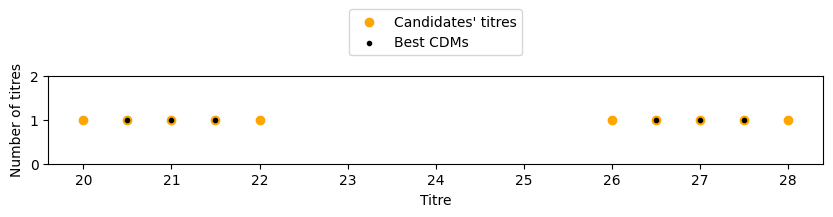

In [22]:
'''
This awards the maximum total number of marks to the maximum number of candidates.
If you want it to list its calculated results, change print_info to True.
If you want to stop it writing lots of info, change print_info to False.
'''

import numpy as np
import matplotlib.pyplot as plt

# Put all your titres here with a comma after every number.
titres = np.array([
20.0, 20.5, 21.0, 21.5, 22.0,
26.0, 26.5, 27.0, 27.5, 28.0
])

print_info = False

# The range of results.
min, max = np.min(titres), np.max(titres)
# Allowed differneces from CDM.
tol_min, tol_med, tol_max = 0.2, 0.3, 0.5
# Variables to store information.
n_scorers_max, marks_max = 0, 0
cdms = []
print("Median =", np.median(titres))
# Set up a loop through all possible CDMs within the range of results.
value = np.floor(min)
# Make sure the CDMs all end in a 0, 3, 5 or 8 at the 2nd decimal place.
steps = [0.03, 0.02]
i = 0
while value < max:
  value = round(value, 2)
  # Find out how many candidates scored a mark.
  scorers = titres[(titres >= value - tol_max) & (titres <= value + tol_max)]
  n_scorers = len(scorers)
  # If this CDM leads to more candidates scoring a mark than any other CDMs tested so far...
  if n_scorers >= n_scorers_max:
    if n_scorers > n_scorers_max:
      cdms = []
      n_scorers_max = n_scorers
    # Calculate the total number of marks scored by all candidates.
    marks_sum = 0
    for scorer in scorers:
      mark = 1
      if ((scorer >= value - tol_med) & (scorer <= value + tol_med)):
        mark = 2
        if ((scorer >= value - tol_min) & (scorer <= value + tol_min)):
          mark = 3
      marks_sum = marks_sum + mark
    # Talk us through the calculations & logic so we can sanity check it.
    if print_info:
      print("\nCDM =", np.round(value, 2))
      print("Titres which scored a mark =", scorers)
      print("Total marks scored for this CDM =", marks_sum)
    # If this CDM leads to the same total number of marks as the best found so far...
    if marks_sum == marks_max:
      # Add this CDM to the list of best CDMs.
      cdms.append(value)
    # If this CDM leads to the greatest total number of marks...
    elif marks_sum > marks_max:
      # Save this as the best CDM found so far and overwrite the previous best.
      cdms = [value]
      marks_max = marks_sum
  # Continue looping through all possible CDMs.
  value += steps[i % 2]
  i += 1

# Show all of the overall best CDMs.
print(f"\nBest CDMs, all leading to {n_scorers_max} candidates scoring marks and a total of {marks_max} marks over all candidates:")
for cdm in cdms:
  print(cdm)

'''
This shows the distribution of results and best CDMs visually to help
the examiner assess the spread of titres and approriateness of the chosen CDM.
'''

vals, counts = np.unique(titres, return_counts=True)
counts_max = np.max(counts)

fig, ax = plt.subplots(figsize=(10, 10))
for i in range(counts_max):
  x = vals[counts >= i+1]
  y = np.full(len(x), i+1)
  ax.scatter(x, y, marker='o', color='orange')
ax.scatter(None, None, marker='o', color='orange', label="Candidates' titres")
ax.scatter(cdms, np.ones(len(cdms)), marker='.', color='black', label="Best CDMs")
ax.set_aspect(0.5)
ax.set_yticks(range(np.max(counts)+2))
ax.set_xlabel("Titre")
ax.set_ylabel("Number of titres")
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.15))
plt.show()